[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/16PoobcNzQC0y3p_FcbHdewwq3RWKK-hB/view?usp=sharing)

<figure>
<center>
<img src='https://upload.wikimedia.org/wikipedia/commons/a/a2/Colombia_Dane_logo_%282%29.svg', height="75">
<figcaption>Departamento Administrativo Nacional de Estadística - DANE<br> Dirección de Censos y Demografía - DCD<br>GIT Investigación y Desarrollo</figcaption></center>
</figure>

**Mapa estático - DCD - DANE**

#0. Entorno

Para importar archivos de Drive

In [ ]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

Para importar shapefiles

In [ ]:
import geopandas as gpd

Para poner de fondo el contexto de openstreetmap

In [ ]:
%%capture
!pip install contextily
import contextily as ctx

Para lo demás.

In [ ]:
import pandas as pd

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

# Importar


In [ ]:
divipola_mpio = gpd.read_file("/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/MGN_MPIO_POLITICO/MGN_MPIO_POLITICO.shp")
divipola_mpio = divipola_mpio.to_crs(epsg=3857)

In [ ]:
proyeccion = pd.read_excel("/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/DCD-area-proypoblacion-Mun-2020-2035-ActPostCOVID-19.xlsx", converters={'MPIO':str})
proyeccion.rename(columns = {'Población':'Poblacion', 'MPIO':'MPIO_CDPMP'}, inplace = True)

In [ ]:
ensamble = pd.read_csv("/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/mpio_rebp_2021.csv", delimiter="|",
  dtype={
    'MPIO_RESIDENCIA_ADMIN': 'string',
    'TOTAL': 'int64'
  }
)
ensamble.rename(columns = {'MPIO_RESIDENCIA_ADMIN':'MPIO_CDPMP','Total':'P_post_ensamble'}, inplace = True)

In [ ]:
ensamble.head()

,MPIO_CDPMP,P_post_ensamble
0,<NA>,4667221
1,05001,2812023
2,05002,14957
3,05004,1762
4,05021,3997


In [ ]:
divipola_mpio = pd.merge(divipola_mpio, proyeccion, on='MPIO_CDPMP')
divipola_mpio = pd.merge(divipola_mpio, ensamble, on='MPIO_CDPMP')

In [ ]:
divipola_mpio['diferencia_pos'] = pd.DataFrame.abs(divipola_mpio['Poblacion'] - divipola_mpio['P_post_ensamble'])
divipola_mpio['diferencia_pos_rel'] = pd.DataFrame.abs( divipola_mpio['Poblacion'] - divipola_mpio['P_post_ensamble'] )/divipola_mpio['Poblacion']

# mapas totales

In [ ]:
vmin_ = divipola_mpio.P_post_ensamble.min()
vmax_ = divipola_mpio.P_post_ensamble.max()

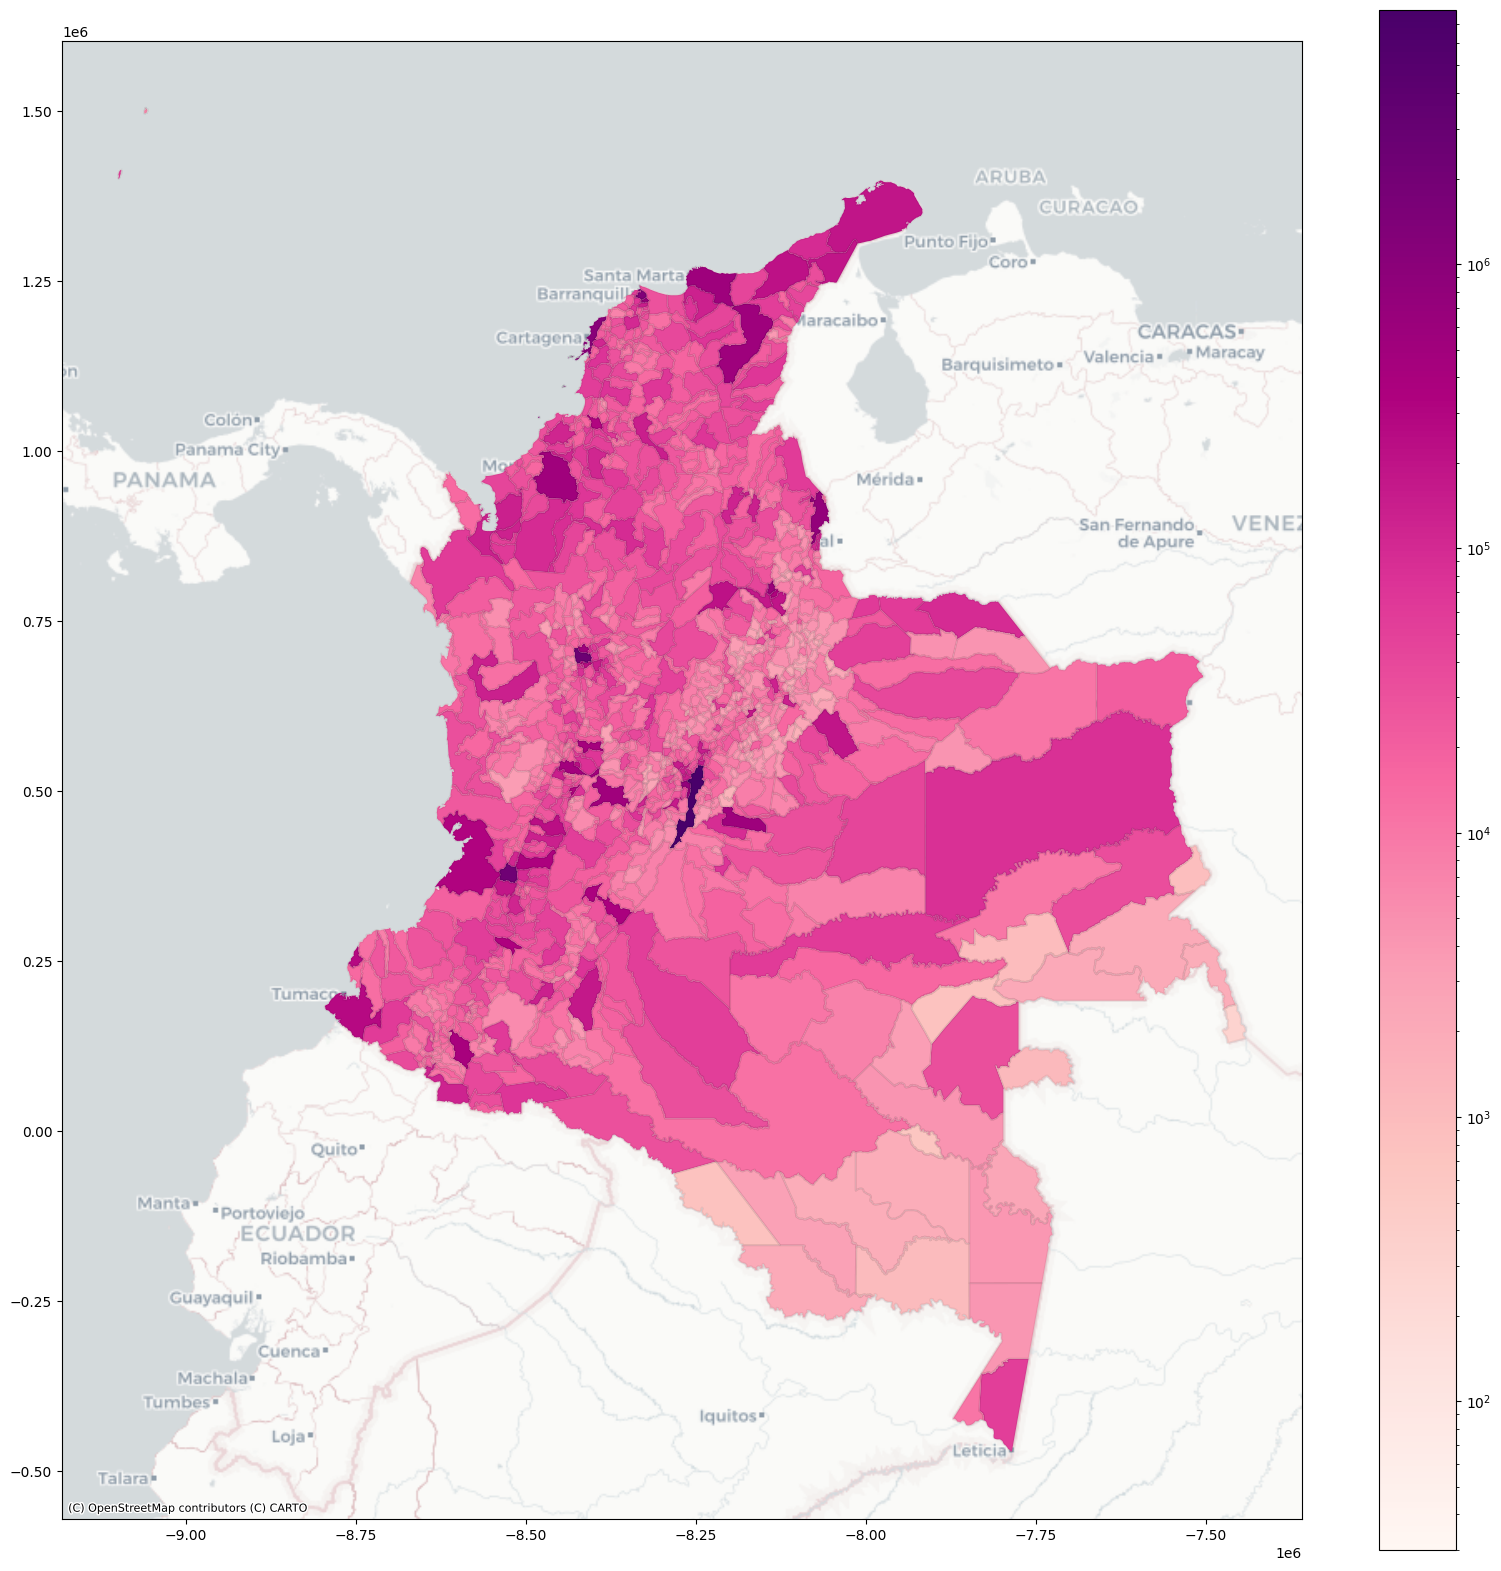

In [ ]:
ax = divipola_mpio.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
divipola_mpio.plot( ax=ax, column='Poblacion', cmap='RdPu', legend=True, norm=matplotlib.colors.LogNorm(vmin=vmin_, vmax=vmax_) )
#ax.set_axis_off()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

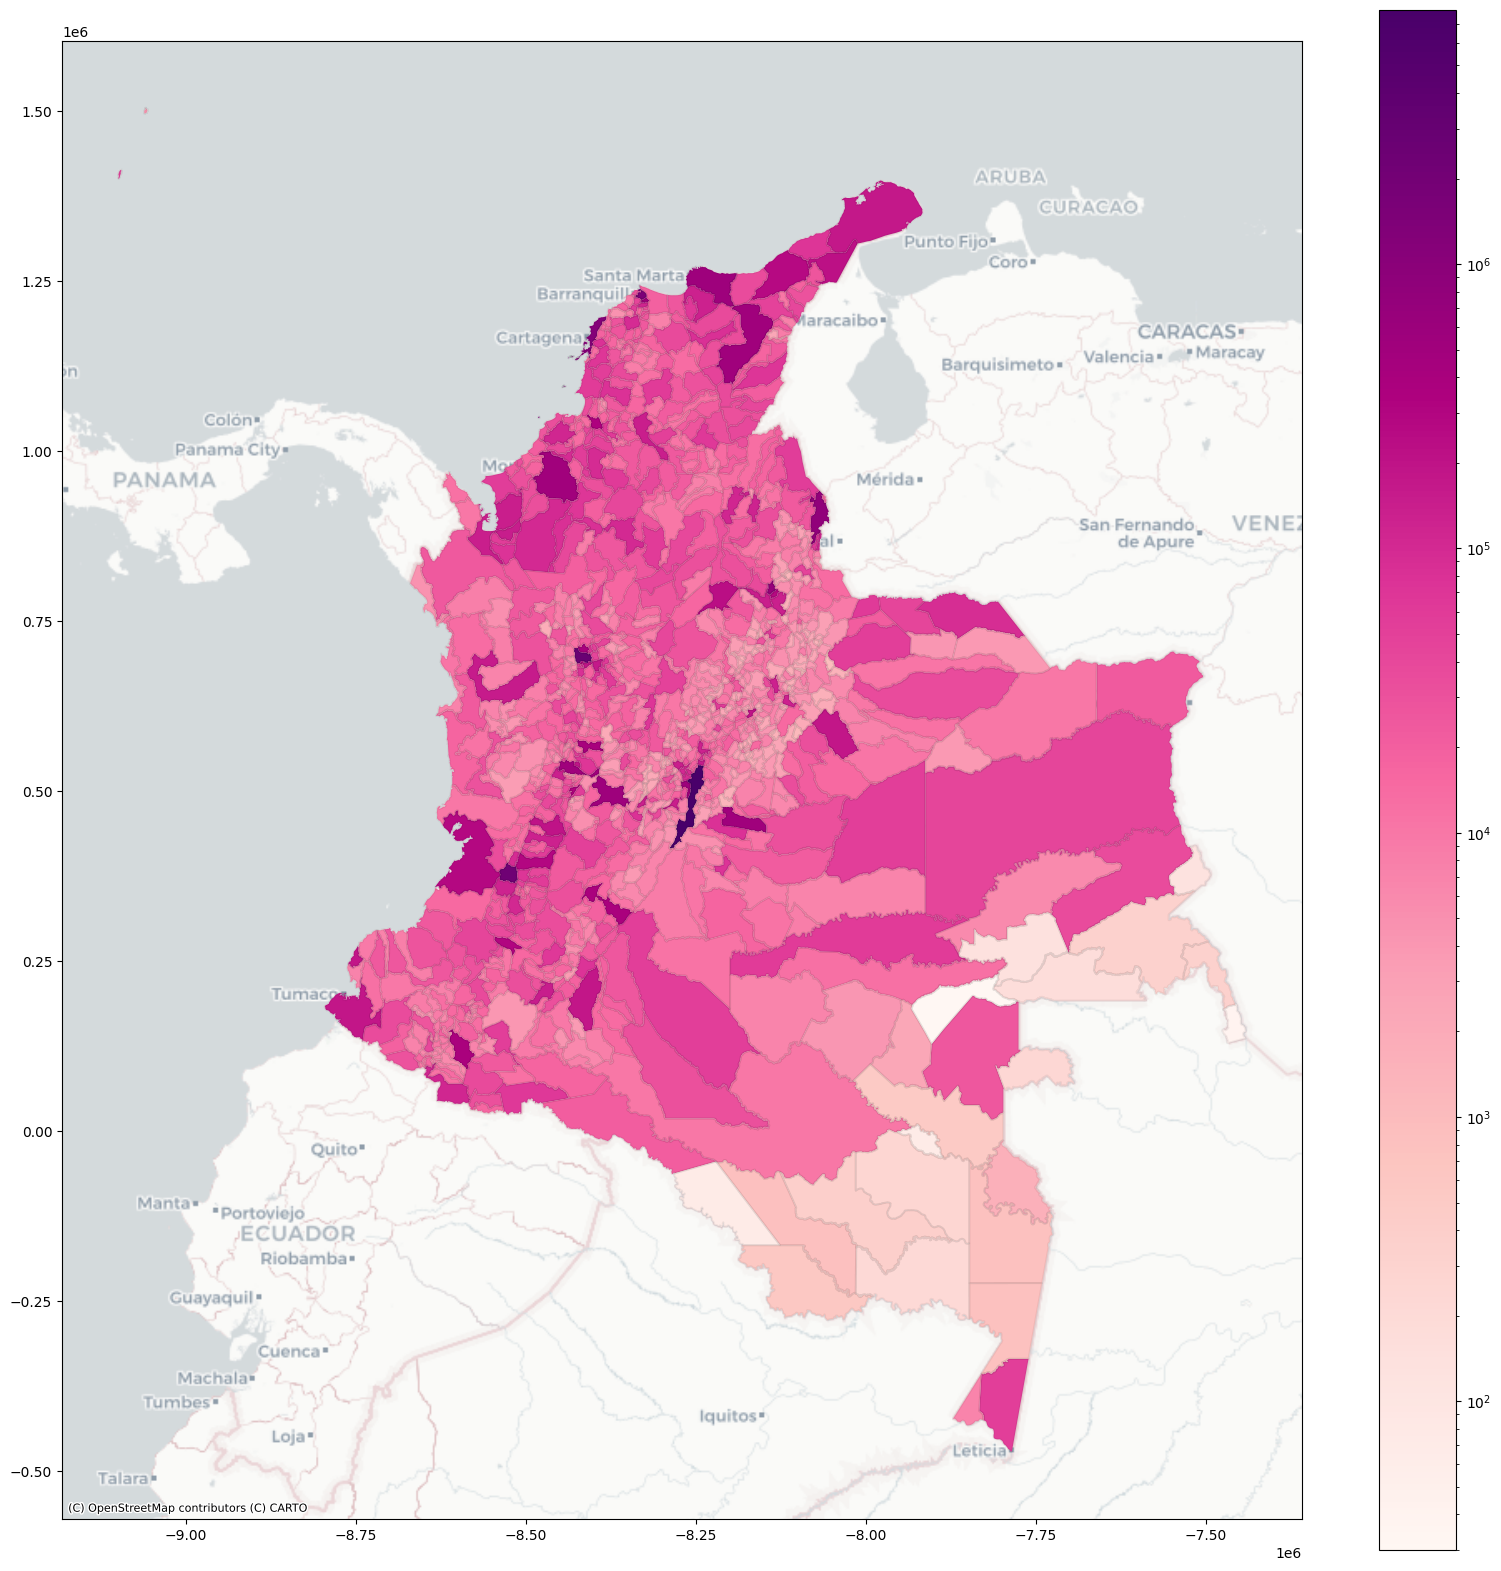

In [ ]:
ax = divipola_mpio.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
divipola_mpio.plot( ax=ax, column='P_post_ensamble', cmap='RdPu', legend=True, norm=matplotlib.colors.LogNorm(vmin=vmin_, vmax=vmax_) )
#ax.set_axis_off()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# mapas diferencias

In [ ]:
vmin_ = divipola_mpio.diferencia_pos.min()
vmax_ = divipola_mpio.diferencia_pos.max()

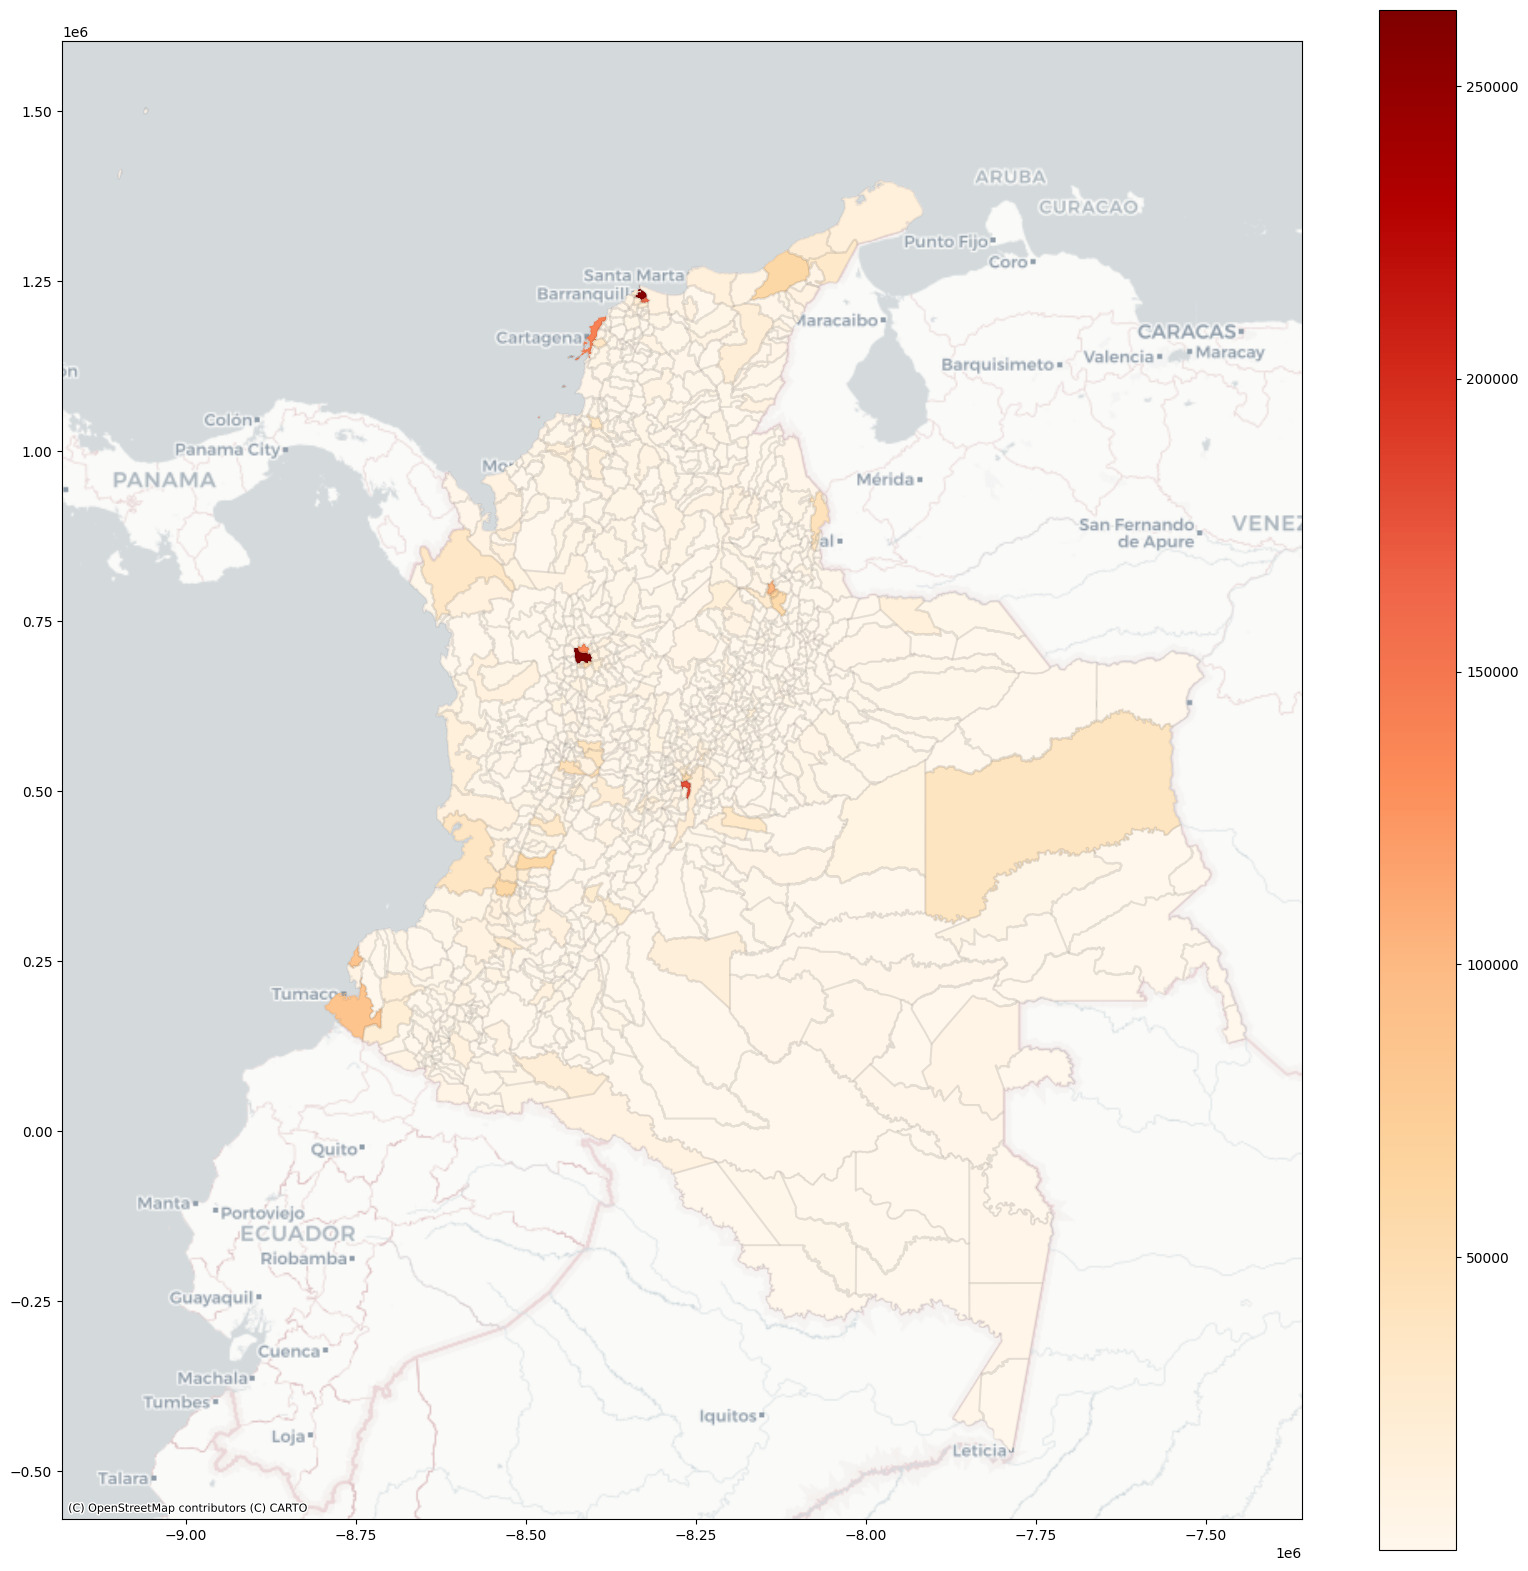

In [ ]:
ax = divipola_mpio.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
divipola_mpio.plot( ax=ax, column='diferencia_pos', cmap='OrRd', legend=True, norm=matplotlib.colors.Normalize(vmin=vmin_, vmax=vmax_) )
#ax.set_axis_off()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

In [ ]:
vmin_ = divipola_mpio.diferencia_pos_rel.min()
vmax_ = divipola_mpio.diferencia_pos_rel.max()

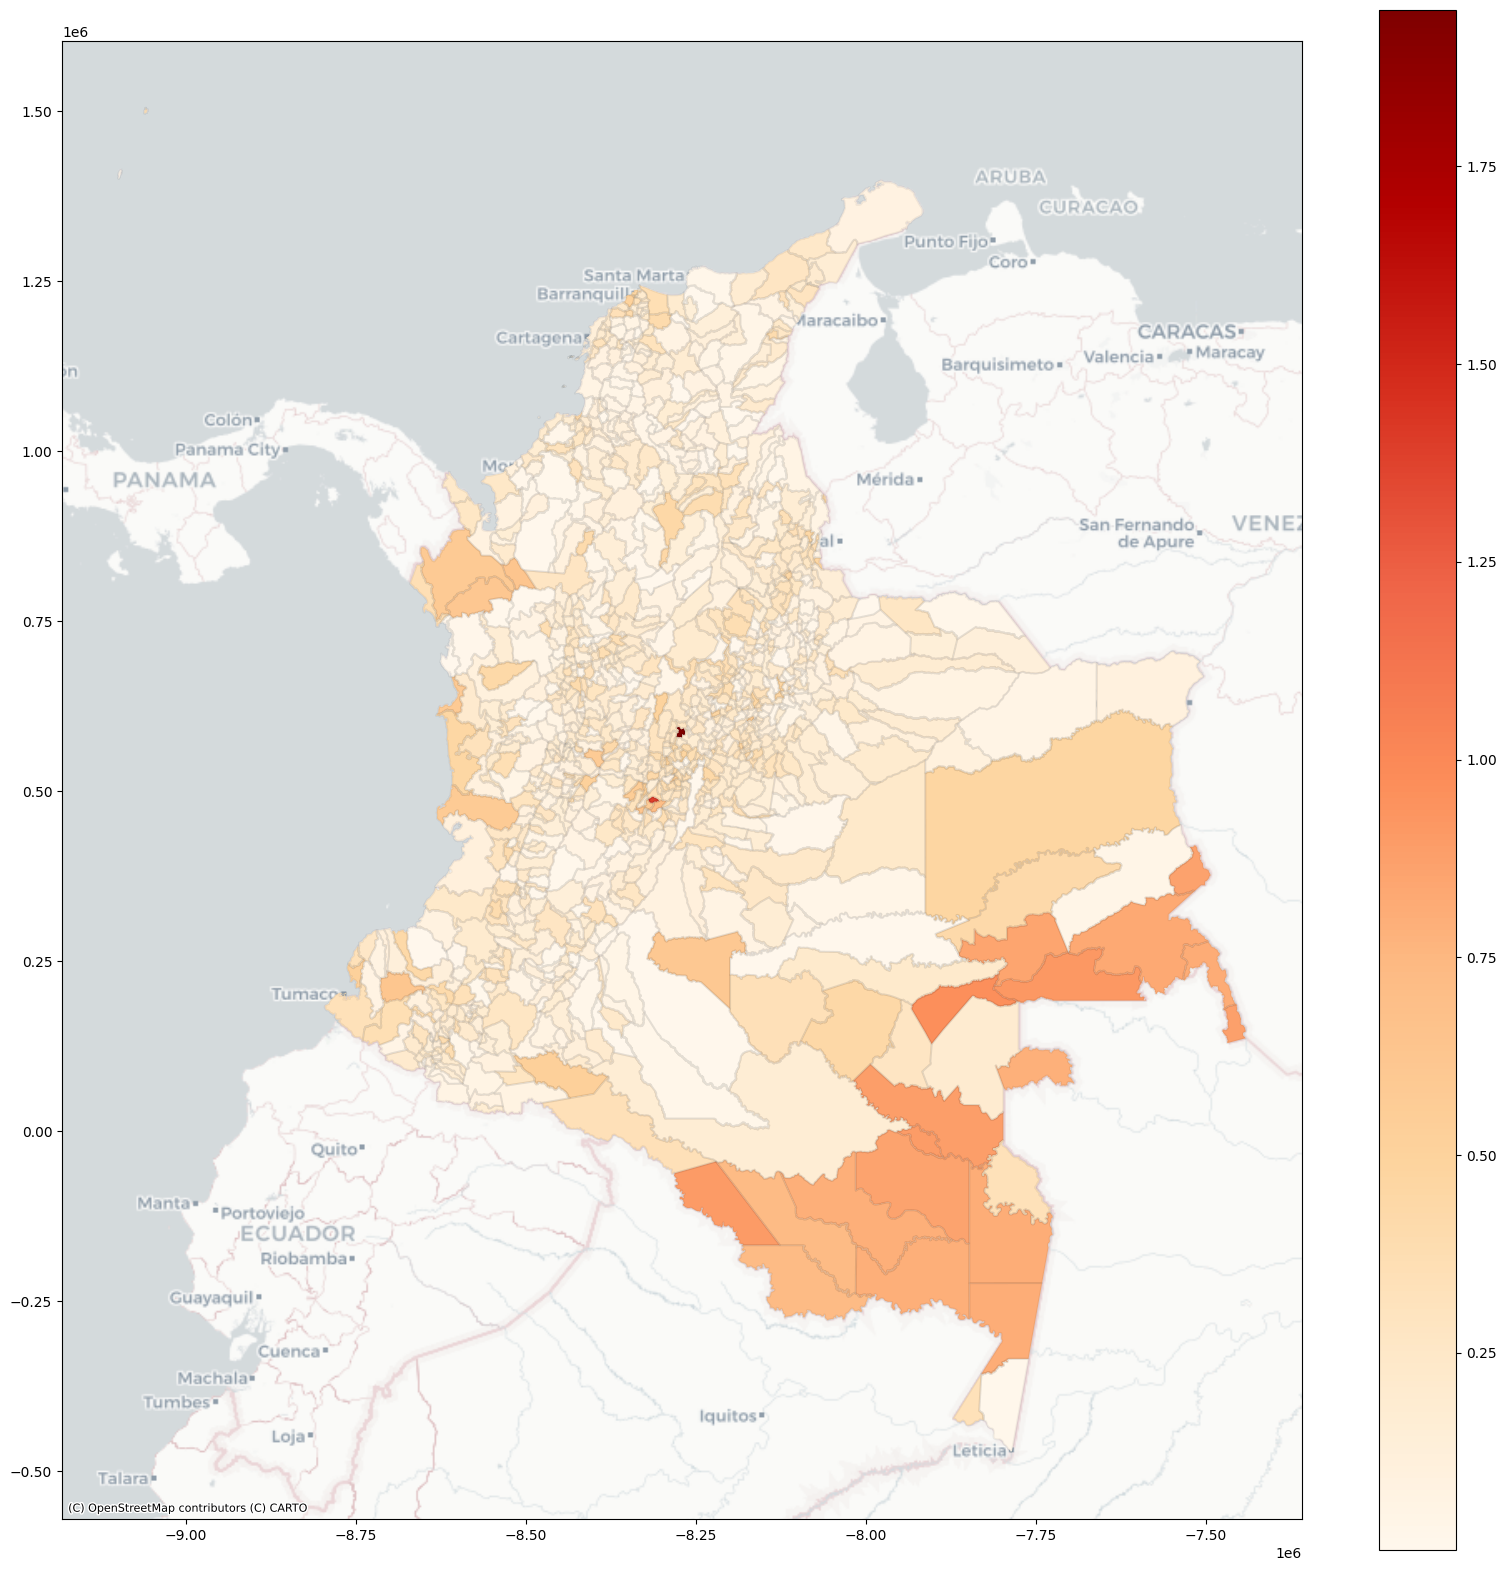

In [ ]:
ax = divipola_mpio.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
divipola_mpio.plot( ax=ax, column='diferencia_pos_rel', cmap='OrRd', legend=True, norm=matplotlib.colors.Normalize(vmin=vmin_, vmax=vmax_) )
#ax.set_axis_off()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Mapas La Guajira

In [ ]:
un_dpto = pd.read_csv('/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/Tabla_REBP2018 EDAD Y SEXO con onevsrest y multiclase.csv', sep=";", thousands='.', dtype={'Municipio':'str', 'Departamento':'str', 'OnevsRest_2018':'float64', 'Multiclase_2018':'float64'})
un_dpto = un_dpto.drop(columns=['SEXO','EDAD'])

In [ ]:
un_dpto = un_dpto.fillna(0).groupby(['Municipio','Departamento']).sum().reset_index()
un_dpto = un_dpto.loc[un_dpto.Departamento=='44']
un_dpto.rename(columns = {'Municipio':'MPIO_CDPMP'}, inplace = True)
un_dpto = un_dpto.drop(columns=['Departamento','OnevsRest_2018'])

In [ ]:
un_dpto_rel = pd.read_csv('/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/JS_Cluster_v2.csv', sep=";", encoding='LATIN1',dtype={'U_MPIO':'str'})
un_dpto_rel = un_dpto_rel[['U_MPIO','POBLACIÓN PROYECCIONES']]
un_dpto_rel.rename(columns = {'U_MPIO':'MPIO_CDPMP','POBLACIÓN PROYECCIONES':'Proyeccion_2018'}, inplace = True)

In [ ]:
divipola_mpio = gpd.read_file("/content/drive/MyDrive/- Trabajo -/- dane -/mapa predicciones/MGN_MPIO_POLITICO/MGN_MPIO_POLITICO.shp")
un_dpto = pd.merge(divipola_mpio, un_dpto, on='MPIO_CDPMP')
un_dpto = pd.merge(un_dpto, un_dpto_rel, on='MPIO_CDPMP')

In [ ]:
un_dpto['diferencia_abs'] = pd.DataFrame.abs(un_dpto['Proyeccion_2018'] - un_dpto['Multiclase_2018'])
un_dpto['diferencia_rel'] = pd.DataFrame.abs( un_dpto['Proyeccion_2018'] - un_dpto['Multiclase_2018'] )/un_dpto['Proyeccion_2018']

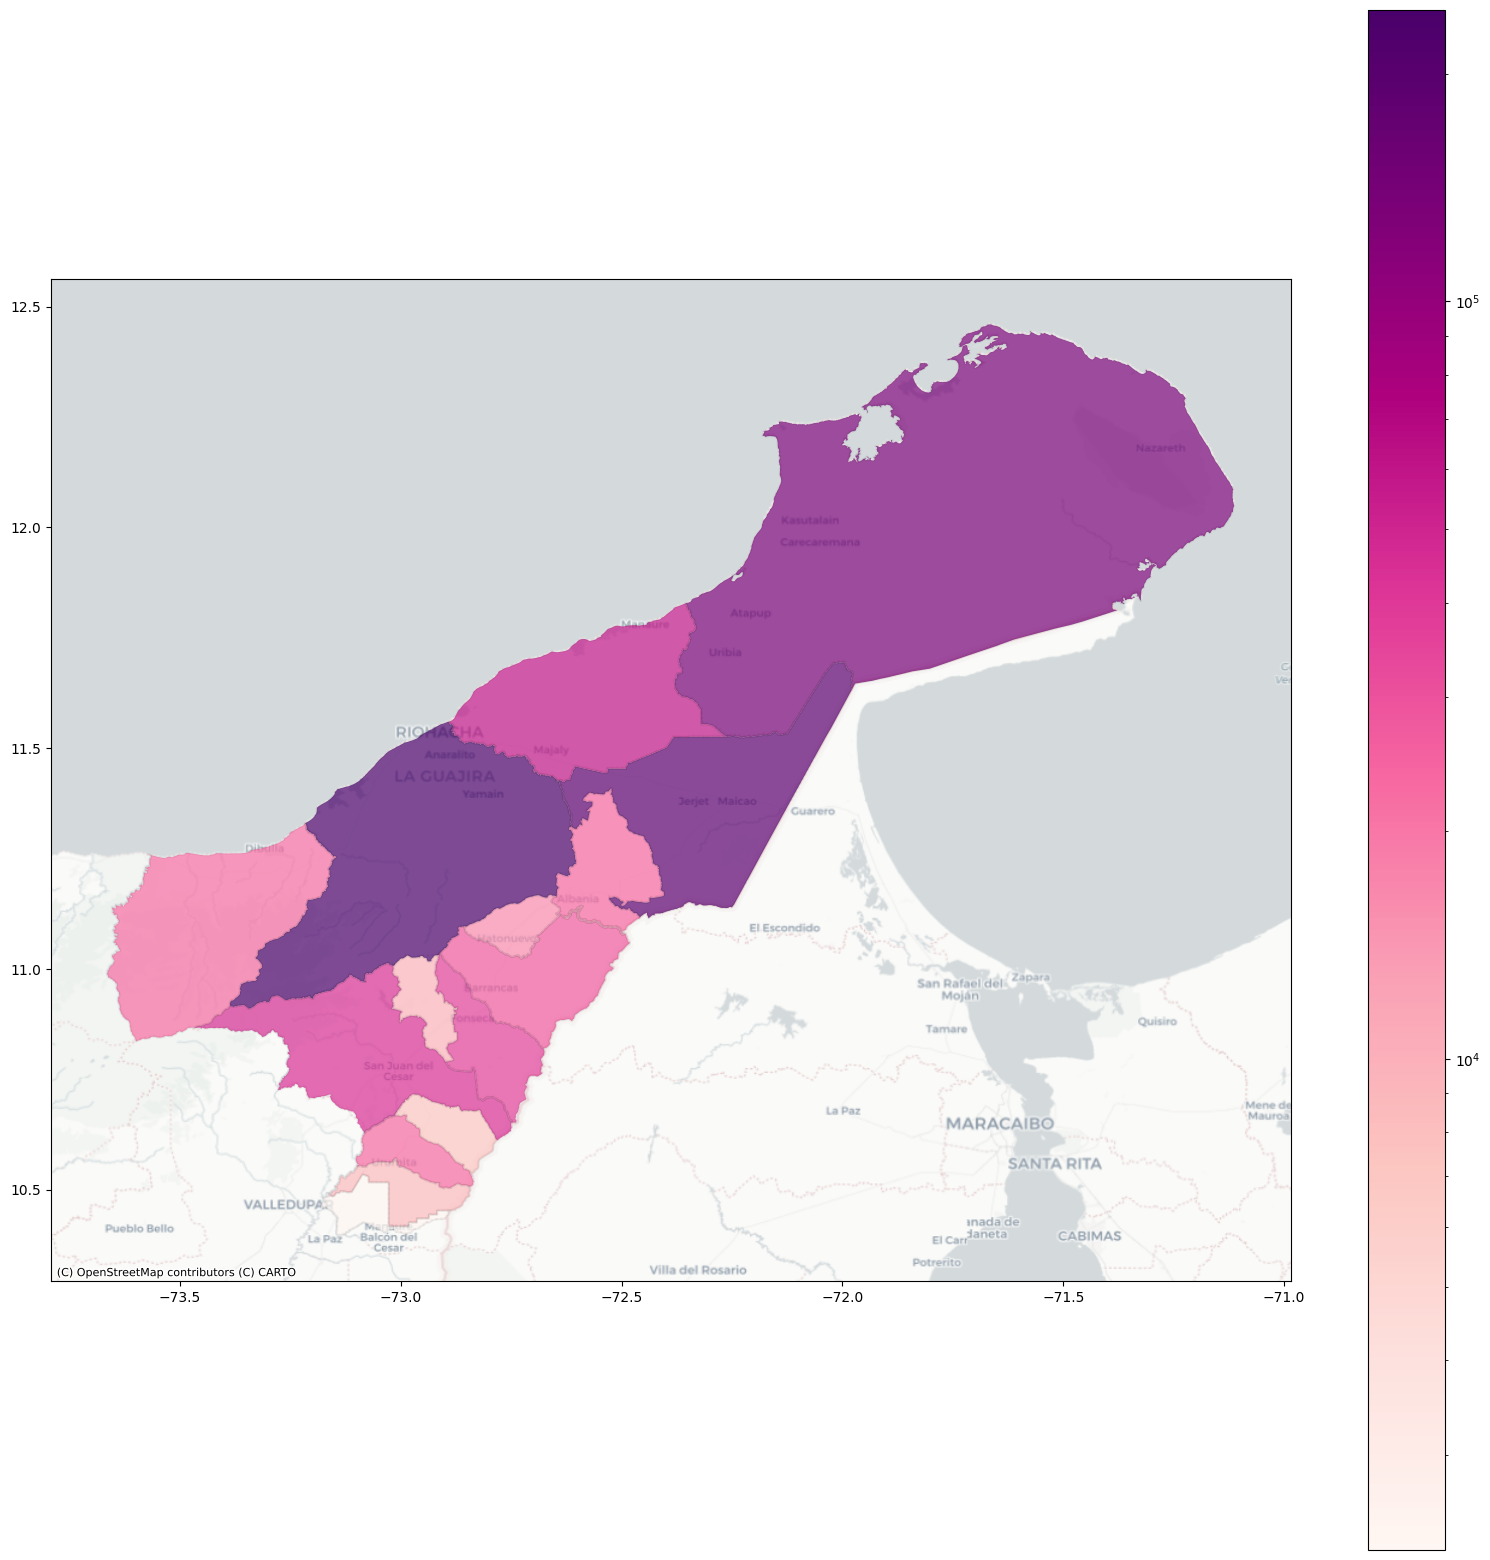

In [ ]:
vmin_ = un_dpto.Multiclase_2018.min()
vmax_ = un_dpto.Multiclase_2018.max()

ax = un_dpto.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
un_dpto.to_crs(epsg=4326).plot( ax=ax, column='Multiclase_2018', cmap='RdPu', legend=True, norm=matplotlib.colors.LogNorm(vmin=vmin_, vmax=vmax_), alpha=0.7 )
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=un_dpto.to_crs(epsg=4326).crs)

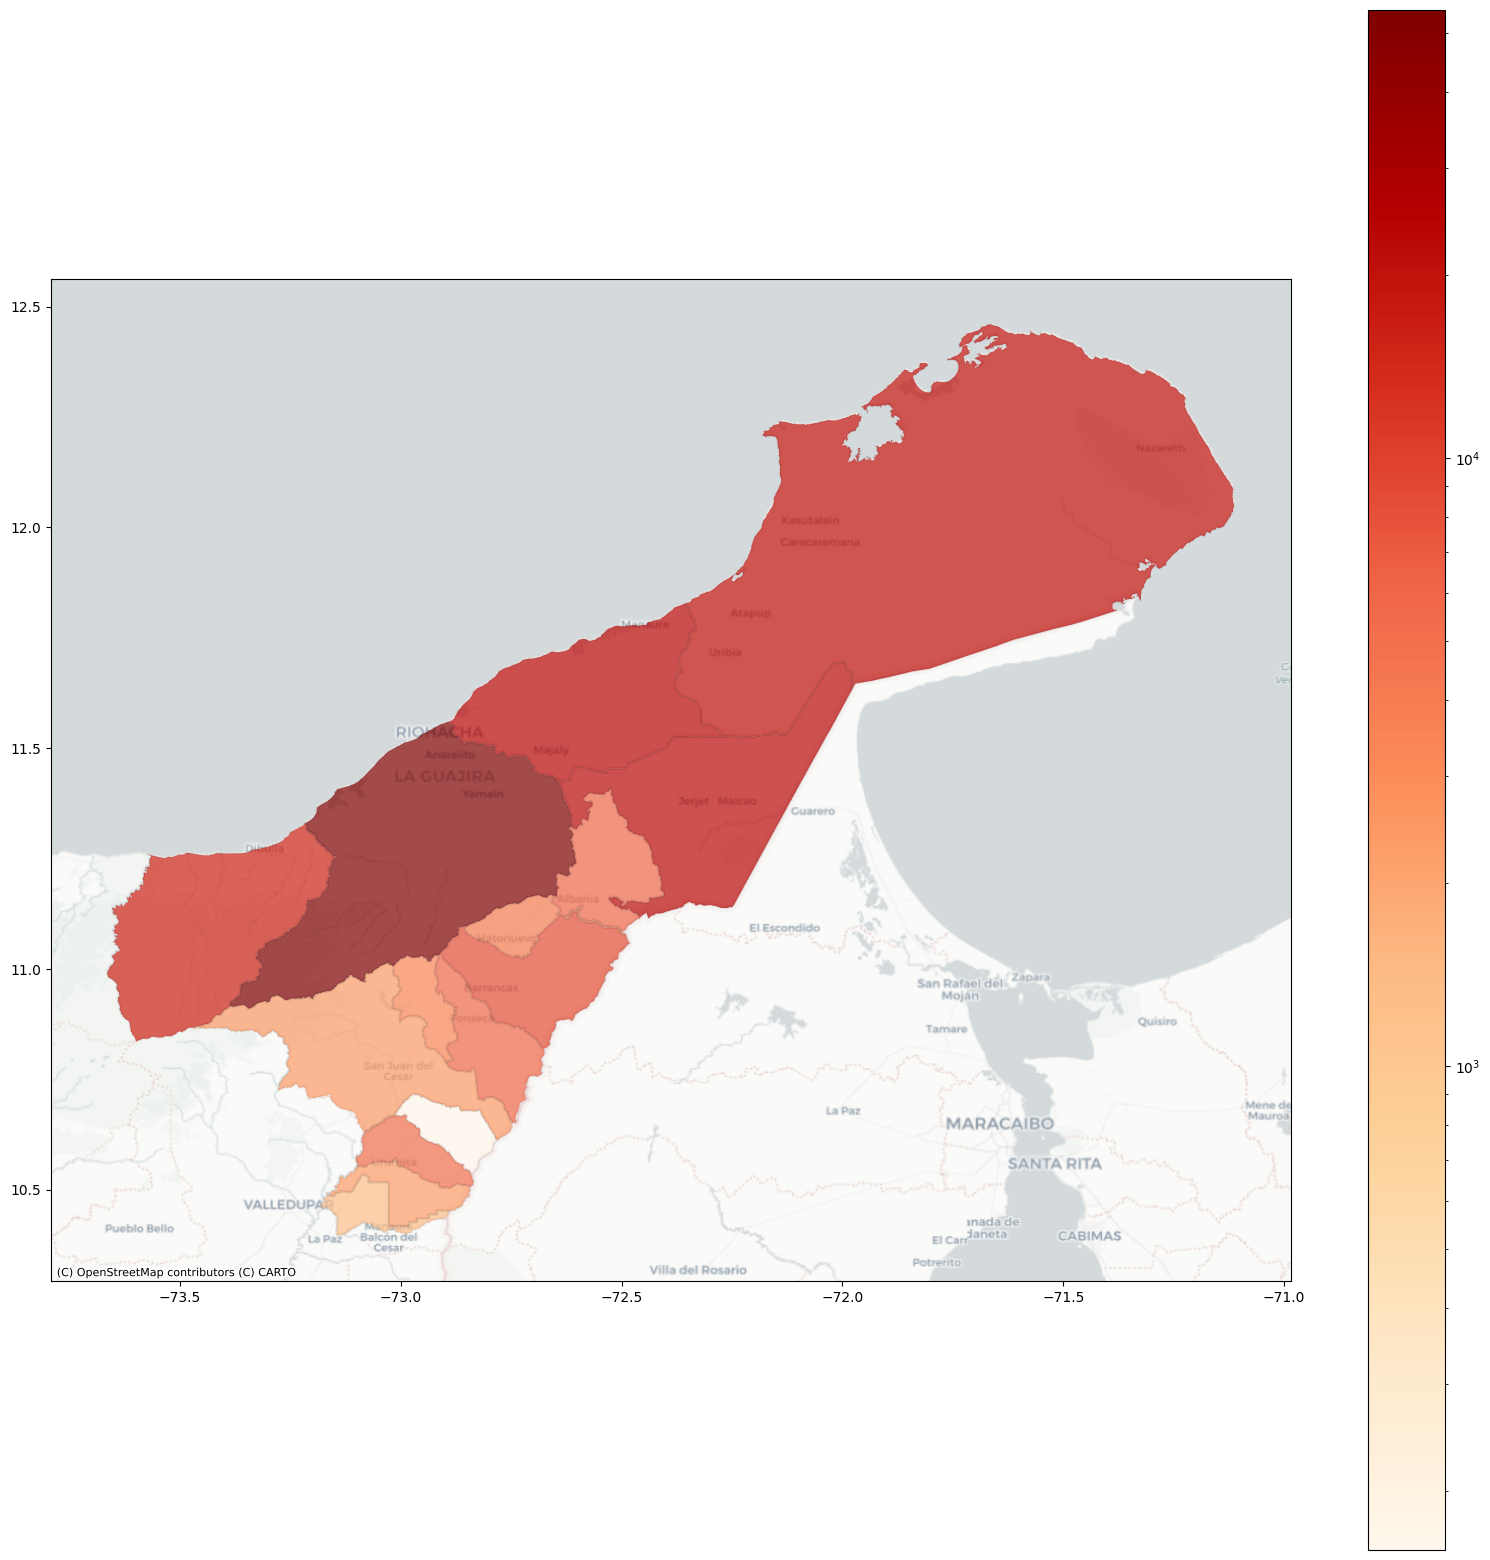

In [ ]:
vmin_ = un_dpto.diferencia_abs.min()
vmax_ = un_dpto.diferencia_abs.max()

ax = un_dpto.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
un_dpto.to_crs(epsg=4326).plot( ax=ax, column='diferencia_abs', cmap='OrRd', legend=True, norm=matplotlib.colors.LogNorm(vmin=vmin_, vmax=vmax_), alpha=0.7 )
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=un_dpto.to_crs(epsg=4326).crs)

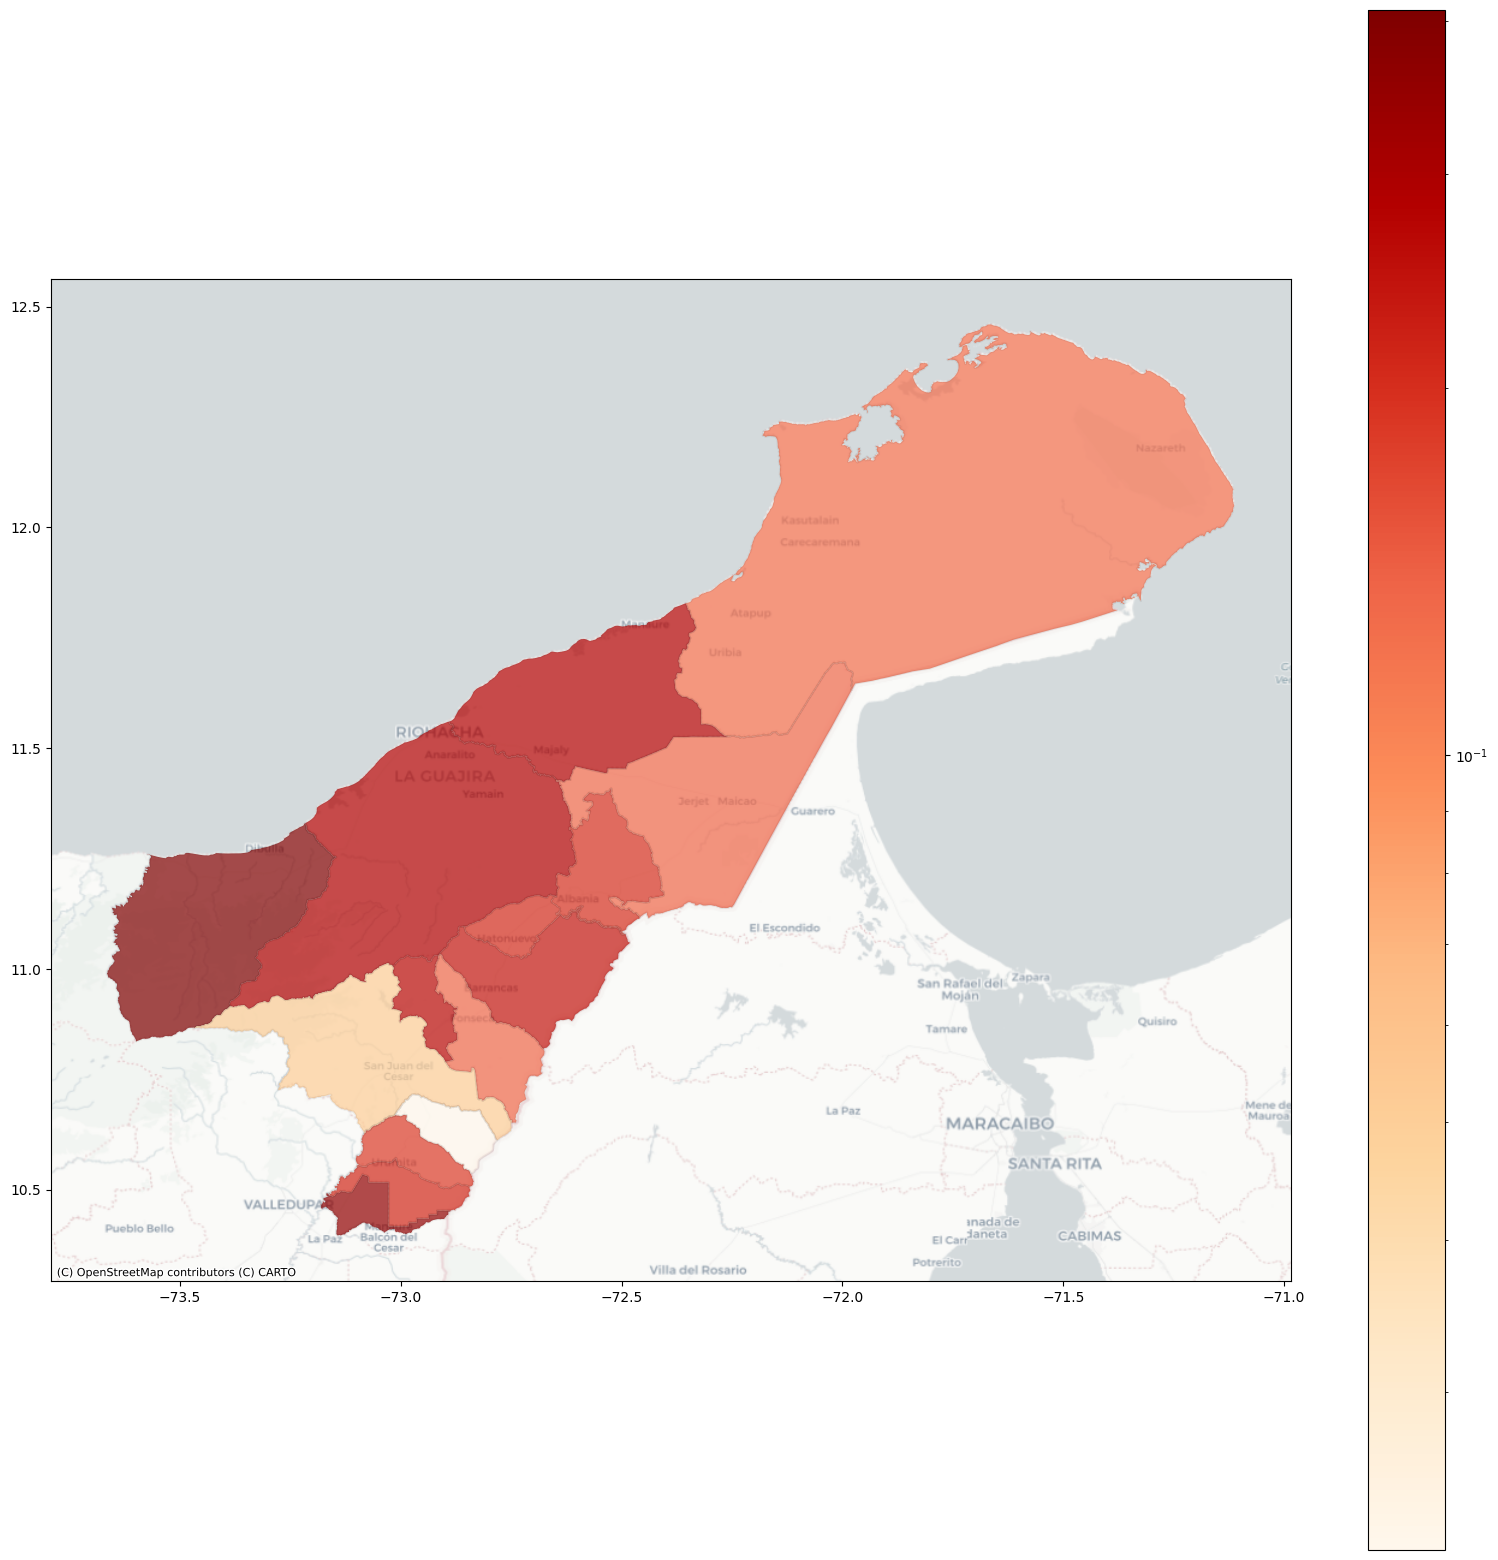

In [ ]:
vmin_ = un_dpto.diferencia_rel.min()
vmax_ = un_dpto.diferencia_rel.max()

ax = un_dpto.boundary.plot(figsize=(20,20), edgecolor='k', alpha=0.05)
un_dpto.to_crs(epsg=4326).plot( ax=ax, column='diferencia_rel', cmap='OrRd', legend=True, norm=matplotlib.colors.LogNorm(vmin=vmin_, vmax=vmax_), alpha=0.7 )
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=un_dpto.to_crs(epsg=4326).crs)